# Cell 1: Setup and Imports

In [2]:

import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Gensim for loading models
from gensim.models import FastText

# scikit-learn for alignment and evaluation
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cosine
from scipy.linalg import orthogonal_procrustes

import warnings
warnings.filterwarnings('ignore')

print("✓ Imports loaded")

✓ Imports loaded


In [9]:
# Cell 2: Load Trained Models (FIXED)

models_dir = Path("models")
data_dir = Path("../data/processed")

# Define TrainingCallback class BEFORE loading models
# (This was in Notebook 2 but needs to be here too for unpickling)
from gensim.models.callbacks import CallbackAny2Vec

class TrainingCallback(CallbackAny2Vec):
    """Callback to monitor training progress"""
    def __init__(self):
        self.epoch = 0
        self.losses = []
    
    def on_epoch_begin(self, model):
        print(f"Epoch {self.epoch + 1} starting...", end=' ')
    
    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        self.losses.append(loss)
        print(f"Loss: {loss:,.0f}")
        self.epoch += 1

print("Loading trained models...")

# Load Egyptian FastText
egyptian_ft = FastText.load(str(models_dir / "egyptian_fasttext.model"))
print(f"✓ Egyptian FastText loaded: {len(egyptian_ft.wv):,} words")

# Load German FastText
german_ft = FastText.load(str(models_dir / "german_fasttext.model"))
print(f"✓ German FastText loaded: {len(german_ft.wv):,} words")

# Try to load pre-trained German if available
pretrained_path = "cc.de.300.bin"
try:
    print(f"\nAttempting to load pre-trained German from {pretrained_path}...")
    german_ft_pretrained = FastText.load_fasttext_format(pretrained_path)
    german_ft_final = german_ft_pretrained
    print(f"✓ Using pre-trained German FastText: {len(german_ft_final.wv):,} words")
except:
    german_ft_final = german_ft
    print(f"✓ Using trained German FastText: {len(german_ft_final.wv):,} words")

print("\n" + "="*60)

Loading trained models...
✓ Egyptian FastText loaded: 17,041 words
✓ German FastText loaded: 16,252 words

Attempting to load pre-trained German from cc.de.300.bin...
✓ Using trained German FastText: 16,252 words



In [10]:
# Cell 3: Load Supporting Data

# Load lexicon for anchor selection
try:
    lexicon_df = pd.read_parquet(data_dir / "lexicon.parquet")
    print(f"✓ Lexicon loaded: {len(lexicon_df):,} entries")
except FileNotFoundError:
    lexicon_df = None
    print("⚠ No lexicon found")

# Load cleaned datasets for translation pairs
bbaw_clean = pd.read_parquet(data_dir / "bbaw_clean.parquet")
tla_clean = pd.read_parquet(data_dir / "tla_clean.parquet")

print(f"✓ BBAW loaded: {len(bbaw_clean):,} pairs")
print(f"✓ TLA loaded: {len(tla_clean):,} pairs")

✓ Lexicon loaded: 11,727 entries
✓ BBAW loaded: 99,821 pairs
✓ TLA loaded: 12,768 pairs


In [11]:
# Cell 4: Build Translation Dictionary (Egyptian → German)

def build_translation_dict(bbaw_df, tla_df, min_freq=2):
    """
    Build Egyptian → German translation dictionary from parallel data.
    Returns dict with occurrence counts.
    """
    from collections import defaultdict
    
    # Tokenizers from Notebook 1
    def tokenize_egyptian(text):
        return text.split()
    
    def tokenize_german(text):
        import re
        text = text.lower()
        return re.findall(r'\b\w+\b', text)
    
    # Count translations
    translation_counts = defaultdict(lambda: defaultdict(int))
    
    print("Building translation dictionary from BBAW...")
    for _, row in tqdm(bbaw_df.iterrows(), total=len(bbaw_df)):
        egy_tokens = tokenize_egyptian(row['transcription_clean'])
        ger_tokens = tokenize_german(row['translation_clean'])
        
        # Simple heuristic: if sentence is similar length, likely word-level alignment
        if len(egy_tokens) > 0 and len(ger_tokens) > 0:
            ratio = len(ger_tokens) / len(egy_tokens)
            if 0.5 <= ratio <= 2.0:  # Reasonable length ratio
                for egy_word in egy_tokens:
                    for ger_word in ger_tokens:
                        translation_counts[egy_word][ger_word] += 1
    
    print("Building translation dictionary from TLA...")
    for _, row in tqdm(tla_df.iterrows(), total=len(tla_df)):
        egy_tokens = tokenize_egyptian(row['transliteration_clean'])
        ger_tokens = tokenize_german(row['translation_clean'])
        
        if len(egy_tokens) > 0 and len(ger_tokens) > 0:
            ratio = len(ger_tokens) / len(egy_tokens)
            if 0.5 <= ratio <= 2.0:
                for egy_word in egy_tokens:
                    for ger_word in ger_tokens:
                        translation_counts[egy_word][ger_word] += 1
    
    # Convert to translation dictionary (keep most frequent translation)
    translation_dict = {}
    for egy_word, ger_translations in translation_counts.items():
        if sum(ger_translations.values()) >= min_freq:
            # Get most frequent German translation
            best_ger = max(ger_translations.items(), key=lambda x: x[1])
            translation_dict[egy_word] = {
                'translation': best_ger[0],
                'count': best_ger[1],
                'alternatives': dict(ger_translations)
            }
    
    return translation_dict

# Build translation dictionary
print("="*60)
print("BUILDING TRANSLATION DICTIONARY")
print("="*60)
translation_dict = build_translation_dict(bbaw_clean, tla_clean, min_freq=3)

print(f"\n✓ Translation dictionary built: {len(translation_dict):,} Egyptian words")

# Show examples
print("\nSample translations:")
sample_words = list(translation_dict.keys())[:10]
for word in sample_words:
    trans = translation_dict[word]
    print(f"  {word} → {trans['translation']} (count: {trans['count']})")

BUILDING TRANSLATION DICTIONARY
Building translation dictionary from BBAW...


  0%|          | 0/99821 [00:00<?, ?it/s]

Building translation dictionary from TLA...


  0%|          | 0/12768 [00:00<?, ?it/s]


✓ Translation dictionary built: 46,235 Egyptian words

Sample translations:
  pḏ,wt-9 → die (count: 7)
  n → der (count: 25962)
  =f → der (count: 27304)
  ḥtr? → die (count: 1)
  m → der (count: 25485)
  ḥtr → und (count: 83)
  tp,j → der (count: 175)
  ꜥꜣ → der (count: 1145)
  ḥm → majestät (count: 1574)
  Ꜥꜣ-nḫt,w → das (count: 1)


In [12]:
# Cell 5: Select Anchor Words Using Lexicon Occurrence Scores

def select_anchors_from_lexicon(lexicon_df, translation_dict, egyptian_ft, german_ft, 
                                min_occurrence=10.0, min_translation_count=5):
    """
    Select high-quality anchor words using lexicon occurrence scores.
    These are words we're confident about for alignment.
    """
    anchors = []
    
    if lexicon_df is None:
        print("⚠ No lexicon available, using translation_dict only")
        return select_anchors_simple(translation_dict, egyptian_ft, german_ft)
    
    print(f"Selecting anchors with occurrence ≥ {min_occurrence}...")
    
    for _, entry in tqdm(lexicon_df.iterrows(), total=len(lexicon_df)):
        if entry['occurrence'] < min_occurrence:
            continue
        
        egy_word = entry['transliteration']
        
        # Check if we have translation
        if egy_word not in translation_dict:
            continue
        
        trans_info = translation_dict[egy_word]
        
        # Require minimum translation frequency
        if trans_info['count'] < min_translation_count:
            continue
        
        ger_word = trans_info['translation']
        
        # Both words must be in vocabularies
        if egy_word in egyptian_ft.wv and ger_word in german_ft.wv:
            anchors.append({
                'egyptian': egy_word,
                'german': ger_word,
                'lexicon_occurrence': entry['occurrence'],
                'translation_count': trans_info['count'],
                'weight': entry['occurrence'] * np.log1p(trans_info['count'])  # Combined weight
            })
    
    return anchors

def select_anchors_simple(translation_dict, egyptian_ft, german_ft, min_count=10):
    """
    Fallback: Select anchors from translation dict only (no lexicon).
    """
    anchors = []
    
    for egy_word, trans_info in translation_dict.items():
        if trans_info['count'] < min_count:
            continue
        
        ger_word = trans_info['translation']
        
        if egy_word in egyptian_ft.wv and ger_word in german_ft.wv:
            anchors.append({
                'egyptian': egy_word,
                'german': ger_word,
                'lexicon_occurrence': 0,
                'translation_count': trans_info['count'],
                'weight': np.log1p(trans_info['count'])
            })
    
    return anchors

# Select anchors
print("="*60)
print("SELECTING ANCHOR WORDS")
print("="*60)

if lexicon_df is not None:
    anchors = select_anchors_from_lexicon(
        lexicon_df, translation_dict, egyptian_ft, german_ft_final,
        min_occurrence=10.0,
        min_translation_count=5
    )
else:
    anchors = select_anchors_simple(
        translation_dict, egyptian_ft, german_ft_final,
        min_count=10
    )

print(f"\n✓ Selected {len(anchors):,} anchor word pairs")

# Convert to DataFrame for easier manipulation
anchors_df = pd.DataFrame(anchors)

print("\nAnchor statistics:")
print(f"  Mean translation count: {anchors_df['translation_count'].mean():.1f}")
print(f"  Median translation count: {anchors_df['translation_count'].median():.1f}")
if lexicon_df is not None:
    print(f"  Mean lexicon occurrence: {anchors_df['lexicon_occurrence'].mean():.1f}")
    print(f"  Median lexicon occurrence: {anchors_df['lexicon_occurrence'].median():.1f}")

# Show top anchors by weight
print("\nTop 20 anchor words by weight:")
top_anchors = anchors_df.nlargest(20, 'weight')
for _, row in top_anchors.iterrows():
    print(f"  {row['egyptian']:15} → {row['german']:15} "
          f"(lex: {row['lexicon_occurrence']:6.1f}, trans: {row['translation_count']:4.0f}, "
          f"weight: {row['weight']:8.1f})")

SELECTING ANCHOR WORDS
Selecting anchors with occurrence ≥ 10.0...


  0%|          | 0/11727 [00:00<?, ?it/s]


✓ Selected 80 anchor word pairs

Anchor statistics:
  Mean translation count: 4608.9
  Median translation count: 530.0
  Mean lexicon occurrence: 119.3
  Median lexicon occurrence: 40.1

Top 20 anchor words by weight:
  =f              → der             (lex:  597.4, trans: 27304, weight:   6102.5)
  =t              → du              (lex:  654.6, trans:  251, weight:   3619.3)
  r               → der             (lex:  357.4, trans: 8482, weight:   3232.7)
  r               → der             (lex:  357.4, trans: 8482, weight:   3232.7)
  r               → der             (lex:  357.4, trans: 8482, weight:   3232.7)
  r               → der             (lex:  357.4, trans: 8482, weight:   3232.7)
  m               → der             (lex:  272.7, trans: 25485, weight:   2767.2)
  m               → der             (lex:  272.7, trans: 25485, weight:   2767.2)
  m               → der             (lex:  272.7, trans: 25485, weight:   2767.2)
  =k              → du              (lex:  251.6

In [13]:
# Cell 6: Extract Anchor Vectors

def get_anchor_matrices(anchors_df, egyptian_ft, german_ft):
    """
    Extract embedding matrices for anchor words.
    Returns normalized matrices and weights.
    """
    egy_vectors = []
    ger_vectors = []
    weights = []
    valid_pairs = []
    
    for _, row in anchors_df.iterrows():
        egy_word = row['egyptian']
        ger_word = row['german']
        
        if egy_word in egyptian_ft.wv and ger_word in german_ft.wv:
            egy_vectors.append(egyptian_ft.wv[egy_word])
            ger_vectors.append(german_ft.wv[ger_word])
            weights.append(row['weight'])
            valid_pairs.append((egy_word, ger_word))
    
    # Convert to numpy arrays
    X = np.array(egy_vectors)  # Egyptian vectors
    Y = np.array(ger_vectors)  # German vectors
    W = np.array(weights)      # Weights
    
    # Normalize weights to sum to 1
    W = W / W.sum()
    
    print(f"Anchor matrices:")
    print(f"  Egyptian (X): {X.shape}")
    print(f"  German (Y):   {Y.shape}")
    print(f"  Weights (W):  {W.shape}")
    
    return X, Y, W, valid_pairs

# Extract anchor matrices
print("="*60)
print("EXTRACTING ANCHOR VECTORS")
print("="*60)

X_anchors, Y_anchors, weights, anchor_pairs = get_anchor_matrices(
    anchors_df, egyptian_ft, german_ft_final
)

print(f"\n✓ Extracted {len(anchor_pairs):,} anchor vector pairs")

EXTRACTING ANCHOR VECTORS
Anchor matrices:
  Egyptian (X): (80, 300)
  German (Y):   (80, 300)
  Weights (W):  (80,)

✓ Extracted 80 anchor vector pairs


In [14]:
# Cell 7: Weighted Procrustes Alignment

def weighted_procrustes(X, Y, weights=None):
    """
    Compute weighted Procrustes alignment.
    
    Find orthogonal matrix W that minimizes:
        sum_i weight_i * ||X_i @ W - Y_i||^2
    
    Args:
        X: Source embeddings (n_samples, n_features)
        Y: Target embeddings (n_samples, n_features)
        weights: Sample weights (n_samples,) - should sum to 1
    
    Returns:
        W: Orthogonal transformation matrix (n_features, n_features)
    """
    # Normalize vectors
    X_norm = normalize(X, norm='l2', axis=1)
    Y_norm = normalize(Y, norm='l2', axis=1)
    
    if weights is None:
        weights = np.ones(len(X)) / len(X)
    
    # Apply weights
    X_weighted = X_norm * np.sqrt(weights)[:, np.newaxis]
    Y_weighted = Y_norm * np.sqrt(weights)[:, np.newaxis]
    
    # Compute SVD: Y_weighted^T @ X_weighted = U @ S @ V^T
    U, S, Vt = np.linalg.svd(Y_weighted.T @ X_weighted)
    
    # Optimal rotation: W = V @ U^T
    W = Vt.T @ U.T
    
    return W

print("="*60)
print("COMPUTING PROCRUSTES ALIGNMENT")
print("="*60)

# Compute transformation matrix
print("Computing weighted Procrustes transformation...")
W_transform = weighted_procrustes(X_anchors, Y_anchors, weights)

print(f"✓ Transformation matrix computed: {W_transform.shape}")
print(f"  Orthogonality check: ||W^T @ W - I|| = {np.linalg.norm(W_transform.T @ W_transform - np.eye(300)):.6f}")
print("  (Should be close to 0)")

COMPUTING PROCRUSTES ALIGNMENT
Computing weighted Procrustes transformation...
✓ Transformation matrix computed: (300, 300)
  Orthogonality check: ||W^T @ W - I|| = 0.000000
  (Should be close to 0)


In [15]:
# Cell 8: Transform All Egyptian Embeddings

def transform_embeddings(egyptian_ft, W_transform):
    """
    Apply Procrustes transformation to all Egyptian embeddings.
    """
    # Get all Egyptian vectors
    vocab = list(egyptian_ft.wv.index_to_key)
    vectors = np.array([egyptian_ft.wv[word] for word in vocab])
    
    # Normalize
    vectors_norm = normalize(vectors, norm='l2', axis=1)
    
    # Transform
    vectors_aligned = vectors_norm @ W_transform
    
    # Re-normalize (optional but recommended)
    vectors_aligned = normalize(vectors_aligned, norm='l2', axis=1)
    
    return vocab, vectors_aligned

print("="*60)
print("TRANSFORMING EGYPTIAN EMBEDDINGS")
print("="*60)

print("Applying transformation to all Egyptian words...")
egyptian_vocab, egyptian_aligned = transform_embeddings(egyptian_ft, W_transform)

print(f"✓ Transformed {len(egyptian_vocab):,} Egyptian word vectors")
print(f"  Aligned embedding shape: {egyptian_aligned.shape}")

# Create dictionary for easy lookup
egyptian_aligned_dict = {word: vec for word, vec in zip(egyptian_vocab, egyptian_aligned)}

TRANSFORMING EGYPTIAN EMBEDDINGS
Applying transformation to all Egyptian words...
✓ Transformed 17,041 Egyptian word vectors
  Aligned embedding shape: (17041, 300)


EVALUATING ALIGNMENT QUALITY

Anchor word alignment quality:
  Mean cosine similarity: 0.526
  Median cosine similarity: 0.435
  Std dev: 0.265


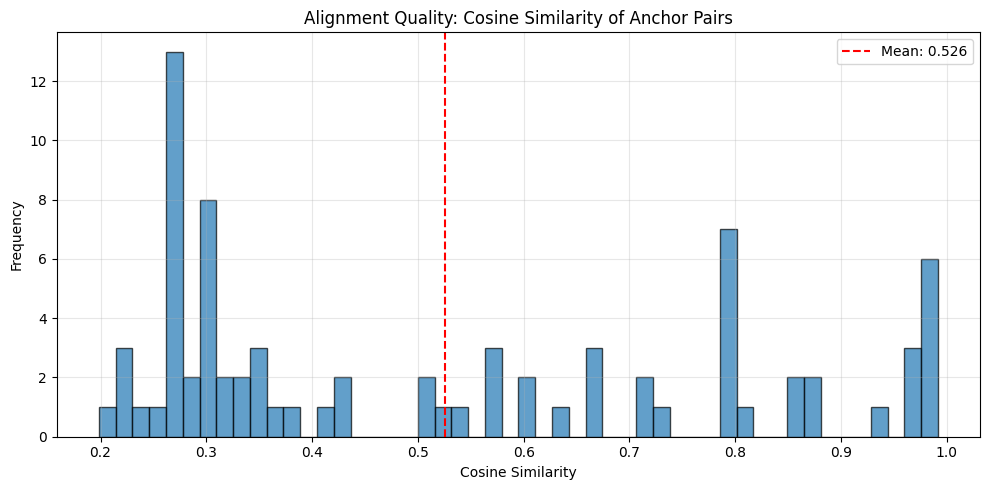


Best aligned anchor pairs:
  =n              → wir             (sim: 0.992)
  dw              → das             (sim: 0.990)
  mwt             → sterben         (sim: 0.984)
  wy              → wehe            (sim: 0.980)
  rf              → ist             (sim: 0.980)
  snb             → und             (sim: 0.979)
  mnw             → aus             (sim: 0.975)
  f               → er              (sim: 0.973)
  ns              → die             (sim: 0.964)
  tf              → des             (sim: 0.939)

Worst aligned anchor pairs:
  sn              → der             (sim: 0.198)
  twt             → der             (sim: 0.221)
  twt             → der             (sim: 0.221)
  tm              → nicht           (sim: 0.228)
  tn              → der             (sim: 0.231)
  pr              → der             (sim: 0.250)
  ky              → der             (sim: 0.267)
  wsr             → der             (sim: 0.267)
  nsw             → der             (sim: 0.267)
  nn        

In [16]:
# Cell 9: Evaluate Alignment Quality on Anchors

def evaluate_anchor_alignment(anchors_df, egyptian_aligned_dict, german_ft):
    """
    Evaluate how well anchor pairs align after transformation.
    """
    cosine_sims = []
    
    for _, row in anchors_df.iterrows():
        egy_word = row['egyptian']
        ger_word = row['german']
        
        if egy_word in egyptian_aligned_dict and ger_word in german_ft.wv:
            egy_vec = egyptian_aligned_dict[egy_word]
            ger_vec = normalize(german_ft.wv[ger_word].reshape(1, -1))[0]
            
            sim = np.dot(egy_vec, ger_vec)
            cosine_sims.append({
                'egyptian': egy_word,
                'german': ger_word,
                'similarity': sim,
                'weight': row['weight']
            })
    
    return pd.DataFrame(cosine_sims)

print("="*60)
print("EVALUATING ALIGNMENT QUALITY")
print("="*60)

# Evaluate on anchor words
anchor_similarities = evaluate_anchor_alignment(anchors_df, egyptian_aligned_dict, german_ft_final)

print(f"\nAnchor word alignment quality:")
print(f"  Mean cosine similarity: {anchor_similarities['similarity'].mean():.3f}")
print(f"  Median cosine similarity: {anchor_similarities['similarity'].median():.3f}")
print(f"  Std dev: {anchor_similarities['similarity'].std():.3f}")

# Show distribution
plt.figure(figsize=(10, 5))
plt.hist(anchor_similarities['similarity'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Alignment Quality: Cosine Similarity of Anchor Pairs')
plt.axvline(anchor_similarities['similarity'].mean(), color='red', 
            linestyle='--', label=f'Mean: {anchor_similarities["similarity"].mean():.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show best and worst aligned pairs
print("\nBest aligned anchor pairs:")
best = anchor_similarities.nlargest(10, 'similarity')
for _, row in best.iterrows():
    print(f"  {row['egyptian']:15} → {row['german']:15} (sim: {row['similarity']:.3f})")

print("\nWorst aligned anchor pairs:")
worst = anchor_similarities.nsmallest(10, 'similarity')
for _, row in worst.iterrows():
    print(f"  {row['egyptian']:15} → {row['german']:15} (sim: {row['similarity']:.3f})")

In [17]:
# Cell 10: Translation Retrieval Evaluation

def translation_retrieval(egy_word, egyptian_aligned_dict, german_ft, topk=10):
    """
    Given an Egyptian word, find nearest German words in aligned space.
    """
    if egy_word not in egyptian_aligned_dict:
        return None
    
    egy_vec = egyptian_aligned_dict[egy_word]
    
    # Get all German vectors
    ger_words = list(german_ft.wv.index_to_key)[:50000]  # Limit for speed
    ger_vectors = np.array([german_ft.wv[word] for word in ger_words])
    ger_vectors_norm = normalize(ger_vectors, norm='l2', axis=1)
    
    # Compute similarities
    sims = ger_vectors_norm @ egy_vec
    
    # Get top-k
    top_indices = np.argsort(sims)[::-1][:topk]
    
    results = [(ger_words[i], sims[i]) for i in top_indices]
    
    return results

print("="*60)
print("TRANSLATION RETRIEVAL TEST")
print("="*60)

# Test translation retrieval on known pairs
test_pairs = anchors_df.nlargest(20, 'weight')

print("\nTranslation retrieval (Top-10 German words for each Egyptian word):")
print("✓ = correct translation in top-10\n")

hits_at_1 = 0
hits_at_5 = 0
hits_at_10 = 0

for _, row in test_pairs.iterrows():
    egy_word = row['egyptian']
    correct_ger = row['german']
    
    results = translation_retrieval(egy_word, egyptian_aligned_dict, german_ft_final, topk=10)
    
    if results:
        retrieved_words = [word for word, _ in results]
        
        # Check if correct translation is retrieved
        if correct_ger in retrieved_words[:1]:
            hits_at_1 += 1
            marker = "✓@1"
        elif correct_ger in retrieved_words[:5]:
            hits_at_5 += 1
            marker = "✓@5"
        elif correct_ger in retrieved_words[:10]:
            hits_at_10 += 1
            marker = "✓@10"
        else:
            marker = "✗"
        
        print(f"{egy_word:15} → {correct_ger:15} {marker}")
        print(f"  Retrieved: {', '.join(retrieved_words[:5])}")
        print()

total = len(test_pairs)
print(f"\nRetrieval Accuracy (Precision@K):")
print(f"  P@1:  {hits_at_1}/{total} = {hits_at_1/total*100:.1f}%")
print(f"  P@5:  {(hits_at_1+hits_at_5)}/{total} = {(hits_at_1+hits_at_5)/total*100:.1f}%")
print(f"  P@10: {(hits_at_1+hits_at_5+hits_at_10)}/{total} = {(hits_at_1+hits_at_5+hits_at_10)/total*100:.1f}%")

TRANSLATION RETRIEVAL TEST

Translation retrieval (Top-10 German words for each Egyptian word):
✓ = correct translation in top-10

=f              → der             ✓@1
  Retrieved: der, des, rḫy, chnumhoteps, geregtaui

=t              → du              ✓@1
  Retrieved: du, fühlst, bist, hinweggehst, solllst

r               → der             ✓@1
  Retrieved: der, 𓍹der, rotäugiger, teilzerstörter_domänenname, kaiaperu

r               → der             ✓@1
  Retrieved: der, 𓍹der, rotäugiger, teilzerstörter_domänenname, kaiaperu

r               → der             ✓@1
  Retrieved: der, 𓍹der, rotäugiger, teilzerstörter_domänenname, kaiaperu

r               → der             ✓@1
  Retrieved: der, 𓍹der, rotäugiger, teilzerstörter_domänenname, kaiaperu

m               → der             ✓@1
  Retrieved: der, heqaib, tuau, sewesertaui𓍺, 𓍹ni

m               → der             ✓@1
  Retrieved: der, heqaib, tuau, sewesertaui𓍺, 𓍹ni

m               → der             ✓@1
  Retrieved: der, heqaib

In [18]:
# Cell 11: Explore Cross-lingual Semantic Space

def find_nearest_german(egy_word, egyptian_aligned_dict, german_ft, topk=5):
    """Helper to find nearest German words"""
    results = translation_retrieval(egy_word, egyptian_aligned_dict, german_ft, topk)
    if results:
        return [f"{word} ({sim:.3f})" for word, sim in results]
    return None

print("="*60)
print("CROSS-LINGUAL SEMANTIC EXPLORATION")
print("="*60)

# Interesting Egyptian words to explore
explore_words = {
    'nṯr': 'god',
    'nswt': 'king', 
    'jmn': 'Amun',
    'rꜥ': 'Re',
    'ḥtp': 'peace/offering',
    'kꜣ': 'ka (life force)',
    'bꜣ': 'ba (soul)',
    'ꜥnḫ': 'life',
    'ḏd': 'speak/say',
    'jrj': 'do/make',
    'nfr': 'good/beautiful',
    'mꜣꜥ.t': 'truth/justice (maat)',
}

print("\nWhere do Egyptian concepts land in German semantic space?\n")

for egy_word, meaning in explore_words.items():
    if egy_word in egyptian_aligned_dict:
        nearest = find_nearest_german(egy_word, egyptian_aligned_dict, german_ft_final, topk=5)
        if nearest:
            print(f"{egy_word} ({meaning}):")
            print(f"  → {', '.join(nearest)}")
            print()

CROSS-LINGUAL SEMANTIC EXPLORATION

Where do Egyptian concepts land in German semantic space?

nṯr (god):
  → zusammenziehungen (0.308), zurückgewiesen (0.304), zurückgehalten (0.303), der (0.301), angetan (0.298)

nswt (king):
  → die (0.385), anzutun (0.311), rḫy (0.305), šfw (0.301), ḥmrq (0.299)

jmn (Amun):
  → ꜥnḏw (0.381), anus (0.380), hoffnungsloser (0.373), anhäufung (0.372), anhäufen (0.372)

rꜥ (Re):
  → er (0.419), ḥmrq (0.365), gemolkenes (0.362), nḫj (0.349), und (0.347)

ḥtp (peace/offering):
  → jasen (0.319), ḏbꜥ (0.312), durchdrungen (0.297), fnṯ (0.296), brand (0.295)

kꜣ (ka (life force)):
  → neujahrsfest (0.297), jahrsanfangsfest (0.292), der (0.286), thothfest (0.286), neujahrestagsfest (0.285)

bꜣ (ba (soul)):
  → der (0.310), ausspucken (0.294), solches (0.289), abscheuliches (0.276), fleisches (0.275)

ꜥnḫ (life):
  → und (0.376), stößt (0.373), spd (0.352), entblößt (0.343), abschlagen (0.326)

ḏd (speak/say):
  → schulzimmer (0.327), mâat (0.312), scheinen 

In [19]:
# Cell 12: Semantic Analogies in Aligned Space

def semantic_analogy(word_a, word_b, word_c, egyptian_aligned_dict, german_ft, topk=5):
    """
    Solve analogy: A is to B as C is to ?
    Example: "pharaoh - king + queen" should give female royal terms
    
    All words can be Egyptian or German (mixed analogies!)
    """
    def get_vector(word):
        if word in egyptian_aligned_dict:
            return egyptian_aligned_dict[word]
        elif word in german_ft.wv:
            return normalize(german_ft.wv[word].reshape(1, -1))[0]
        else:
            return None
    
    vec_a = get_vector(word_a)
    vec_b = get_vector(word_b)
    vec_c = get_vector(word_c)
    
    if vec_a is None or vec_b is None or vec_c is None:
        return None
    
    # Analogy vector: B - A + C
    target_vec = vec_b - vec_a + vec_c
    target_vec = target_vec / np.linalg.norm(target_vec)
    
    # Search in German space
    ger_words = list(german_ft.wv.index_to_key)[:50000]
    ger_vectors = np.array([german_ft.wv[word] for word in ger_words])
    ger_vectors_norm = normalize(ger_vectors, norm='l2', axis=1)
    
    # Compute similarities
    sims = ger_vectors_norm @ target_vec
    
    # Get top-k (excluding input words)
    exclude = {word_a, word_b, word_c}
    results = []
    for i in np.argsort(sims)[::-1]:
        if ger_words[i] not in exclude:
            results.append((ger_words[i], sims[i]))
            if len(results) >= topk:
                break
    
    return results

print("="*60)
print("SEMANTIC ANALOGIES")
print("="*60)

print("\nTesting analogies in aligned Egyptian-German space:\n")

# Test analogies
analogies = [
    ('nswt', 'könig', 'pharao'),  # king → könig, pharaoh → ?
    ('nṯr', 'gott', 'göttin'),    # god → gott, goddess → ?
    ('ḥm', 'majestät', 'könig'),  # majesty → majestät, king → ?
]

for a, b, c in analogies:
    result = semantic_analogy(a, b, c, egyptian_aligned_dict, german_ft_final, topk=5)
    if result:
        print(f"{a} : {b} :: {c} : ?")
        for word, sim in result:
            print(f"  → {word} ({sim:.3f})")
        print()

SEMANTIC ANALOGIES

Testing analogies in aligned Egyptian-German space:

nswt : könig :: pharao : ?
  → köni (0.536)
  → phar (0.530)
  → pharaohs (0.529)
  → pha (0.514)
  → phrarao (0.494)

nṯr : gott :: göttin : ?
  → gött (0.577)
  → göttinen (0.563)
  → göttinnnen (0.491)
  → kronengöttin (0.490)
  → baumgöttin (0.490)

ḥm : majestät :: könig : ?
  → köni (0.505)
  → königin (0.493)
  → könige (0.489)
  → majesty (0.464)
  → oä (0.428)



In [20]:
# Cell 13: Save Aligned Embeddings

output_dir = Path("aligned_models")
output_dir.mkdir(exist_ok=True)

print("="*60)
print("SAVING ALIGNED EMBEDDINGS")
print("="*60)

# Save transformation matrix
np.save(output_dir / "procrustes_transform.npy", W_transform)
print(f"✓ Transformation matrix saved")

# Save aligned Egyptian embeddings
np.save(output_dir / "egyptian_aligned_vectors.npy", egyptian_aligned)
with open(output_dir / "egyptian_aligned_vocab.pkl", 'wb') as f:
    pickle.dump(egyptian_vocab, f)
print(f"✓ Aligned Egyptian embeddings saved")

# Save anchor pairs and evaluation
anchors_df.to_parquet(output_dir / "anchor_pairs.parquet")
anchor_similarities.to_parquet(output_dir / "anchor_similarities.parquet")
print(f"✓ Anchor data saved")

# Save alignment metadata
alignment_metadata = {
    'n_anchors': len(anchors_df),
    'mean_similarity': float(anchor_similarities['similarity'].mean()),
    'median_similarity': float(anchor_similarities['similarity'].median()),
    'transformation_shape': W_transform.shape,
    'egyptian_vocab_size': len(egyptian_vocab),
    'aligned_vector_dim': egyptian_aligned.shape[1]
}

with open(output_dir / "alignment_metadata.json", 'w') as f:
    json.dump(alignment_metadata, f, indent=2)

print(f"✓ Alignment metadata saved")
print(f"\n✓ All aligned models saved to: {output_dir.absolute()}")

SAVING ALIGNED EMBEDDINGS
✓ Transformation matrix saved
✓ Aligned Egyptian embeddings saved
✓ Anchor data saved
✓ Alignment metadata saved

✓ All aligned models saved to: /Users/crashy/Development/heiroglyphy/heiro_v12/notebooks/aligned_models


VISUALIZING ALIGNED SPACE


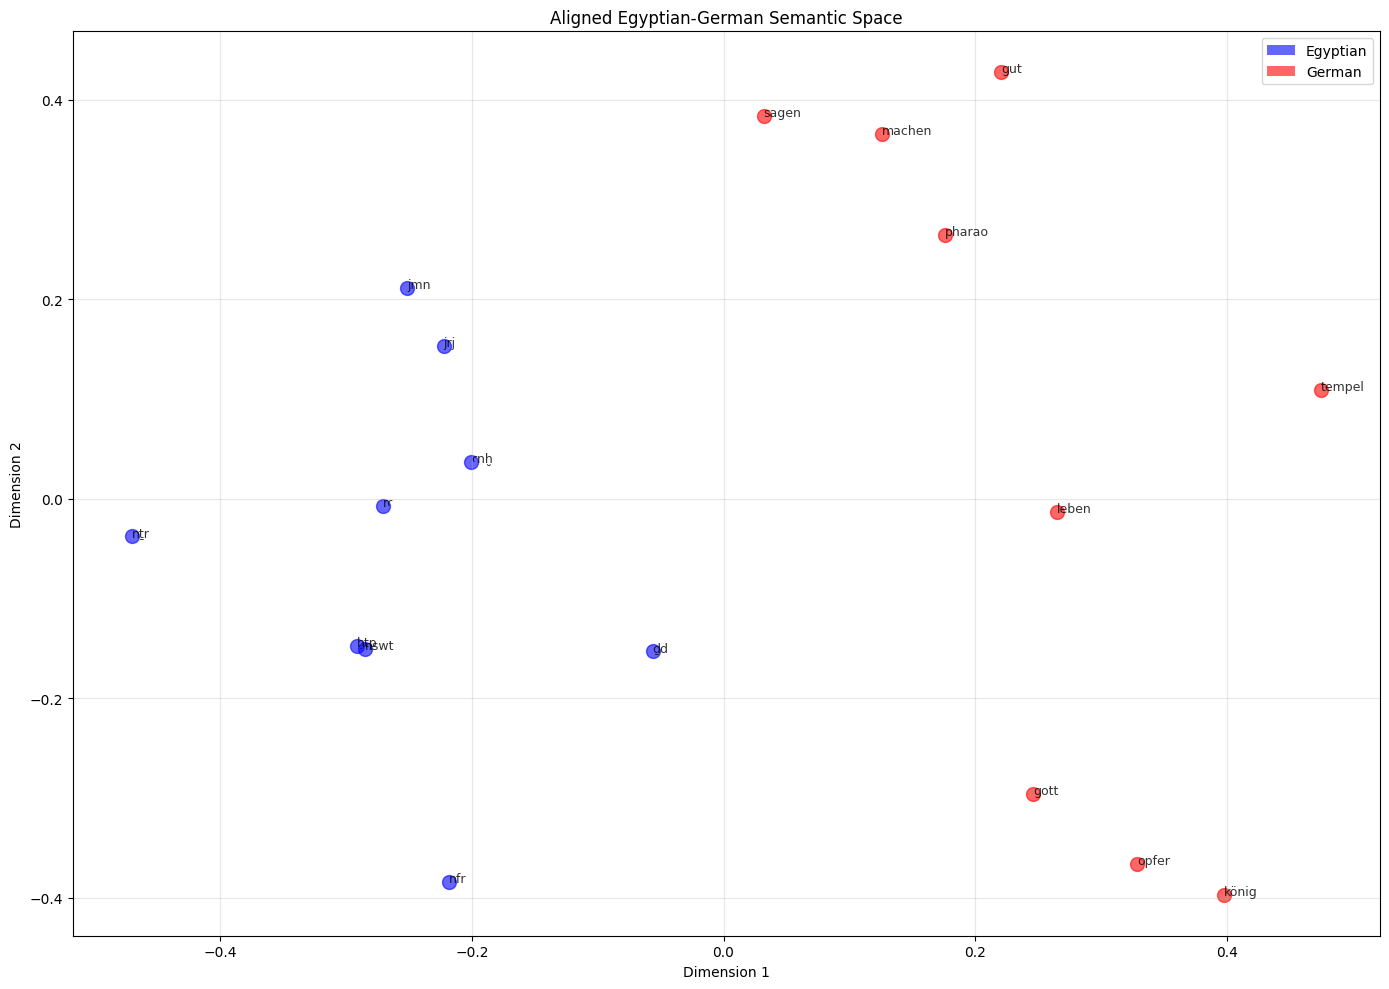

In [21]:
# Cell 14: Visualize Aligned Space

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_aligned_space(egy_words, ger_words, egyptian_aligned_dict, german_ft, method='pca'):
    """
    Visualize Egyptian and German words in the same 2D space after alignment.
    """
    # Collect vectors
    vectors = []
    labels = []
    colors = []
    
    for word in egy_words:
        if word in egyptian_aligned_dict:
            vectors.append(egyptian_aligned_dict[word])
            labels.append(f"egy:{word}")
            colors.append('blue')
    
    for word in ger_words:
        if word in german_ft.wv:
            vec = normalize(german_ft.wv[word].reshape(1, -1))[0]
            vectors.append(vec)
            labels.append(f"de:{word}")
            colors.append('red')
    
    if len(vectors) < 2:
        print("Not enough words for visualization")
        return
    
    vectors = np.array(vectors)
    
    # Reduce to 2D
    if method == 'tsne':
        reducer = TSNE(n_components=2, random_state=42, perplexity=min(30, len(vectors)-1))
    else:
        reducer = PCA(n_components=2, random_state=42)
    
    coords = reducer.fit_transform(vectors)
    
    # Plot
    plt.figure(figsize=(14, 10))
    
    for i, (label, color) in enumerate(zip(labels, colors)):
        plt.scatter(coords[i, 0], coords[i, 1], c=color, s=100, alpha=0.6)
        plt.annotate(label.split(':')[1], (coords[i, 0], coords[i, 1]),
                    fontsize=9, alpha=0.8)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='blue', alpha=0.6, label='Egyptian'),
        Patch(facecolor='red', alpha=0.6, label='German')
    ]
    plt.legend(handles=legend_elements)
    
    plt.title('Aligned Egyptian-German Semantic Space')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualize
print("="*60)
print("VISUALIZING ALIGNED SPACE")
print("="*60)

egy_viz_words = ['nṯr', 'nswt', 'jmn', 'rꜥ', 'ḥtp', 'ꜥnḫ', 'ḏd', 'jrj', 'nfr']
ger_viz_words = ['gott', 'könig', 'pharao', 'tempel', 'opfer', 'leben', 'sagen', 'machen', 'gut']

visualize_aligned_space(egy_viz_words, ger_viz_words, egyptian_aligned_dict, 
                       german_ft_final, method='pca')

In [22]:
# Cell 15: Summary Report

print("="*60)
print("PROCRUSTES ALIGNMENT COMPLETE - SUMMARY")
print("="*60)

print(f"\n📊 Alignment Statistics:")
print(f"  Anchor pairs used: {len(anchors_df):,}")
print(f"  Mean anchor similarity: {anchor_similarities['similarity'].mean():.3f}")
print(f"  Transformation matrix: {W_transform.shape}")

print(f"\n📊 Aligned Embedding Space:")
print(f"  Egyptian vocabulary: {len(egyptian_vocab):,} words")
print(f"  Vector dimensionality: {egyptian_aligned.shape[1]}")
print(f"  All vectors normalized: ✓")

print(f"\n💾 Saved to: {output_dir.absolute()}")
print(f"  - procrustes_transform.npy")
print(f"  - egyptian_aligned_vectors.npy")
print(f"  - egyptian_aligned_vocab.pkl")
print(f"  - anchor_pairs.parquet")
print(f"  - alignment_metadata.json")

print("\n✅ Egyptian embeddings now aligned to German semantic space!")
print("\n🎯 You can now:")
print("  1. Query where Egyptian concepts land in German space")
print("  2. Find cross-lingual semantic similarities")
print("  3. Perform multilingual semantic analogies")
print("  4. Analyze diachronic semantic shifts")
print("  5. (Optional) Project to English space in Notebook 4")

PROCRUSTES ALIGNMENT COMPLETE - SUMMARY

📊 Alignment Statistics:
  Anchor pairs used: 80
  Mean anchor similarity: 0.526
  Transformation matrix: (300, 300)

📊 Aligned Embedding Space:
  Egyptian vocabulary: 17,041 words
  Vector dimensionality: 300
  All vectors normalized: ✓

💾 Saved to: /Users/crashy/Development/heiroglyphy/heiro_v12/notebooks/aligned_models
  - procrustes_transform.npy
  - egyptian_aligned_vectors.npy
  - egyptian_aligned_vocab.pkl
  - anchor_pairs.parquet
  - alignment_metadata.json

✅ Egyptian embeddings now aligned to German semantic space!

🎯 You can now:
  1. Query where Egyptian concepts land in German space
  2. Find cross-lingual semantic similarities
  3. Perform multilingual semantic analogies
  4. Analyze diachronic semantic shifts
  5. (Optional) Project to English space in Notebook 4
